In [32]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer 
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
# collection data
df = pd.read_csv("dataset_for_logistic_regression.csv")
# df

In [34]:
# Convert Text to Numbers (Only for X!)
vectorizer = TfidfVectorizer()
X_numeric = vectorizer.fit_transform(X)
X_numeric.toarray()

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.44878588, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.41366939, 0.32223144,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.31564406],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.29114734]], shape=(50, 156))

C:\Users\E-TIME\AppData\Local\Temp\ipykernel_15148\304137836.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


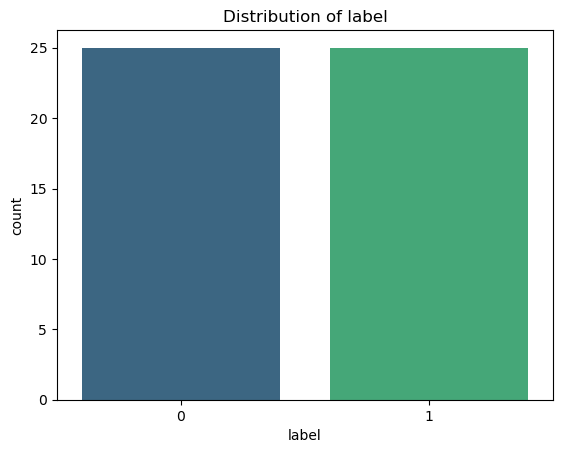

In [35]:
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of label')
plt.show()

In [36]:
# Assign features
X = df["email_text"]
y = df["label"]

In [37]:
# Splitting of dataset into training and testing (randomly)
X_train, X_test, y_train, y_test = train_test_split(X_numeric,y,test_size=0.2)

In [38]:
model = LogisticRegression ()

In [39]:
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
predicted_y = model.predict(X_test)
predicted_y

array([1, 0, 0, 0, 1, 1, 1, 0, 0, 0])

In [45]:
result = accuracy_score(y_test,predicted_y)
result = result * 100
result

100.0

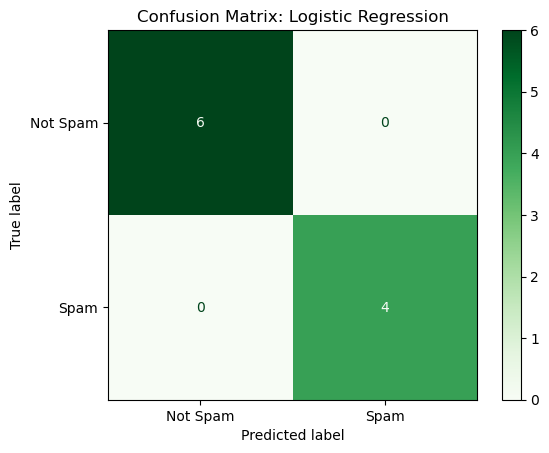

In [46]:
# Plot Confusion Matrix
cm_lr = confusion_matrix(y_test, predicted_y)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not Spam', 'Spam'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()